# Bushbalm Project

## Relevant Modules

In [1]:
# data manipulation 
import pandas as pd 
import numpy as np

# web requests and html manipulation
import requests 
from bs4 import BeautifulSoup
import re 
import backoff
from itertools import chain 
import time

# progress bar
from tqdm import tqdm

# date manipulation
from datetime import datetime as dt 
from datetime import timedelta 

# visualization 
import seaborn as sns 
import matplotlib.pyplot as plt


## Functions

To streamline things + make this process reproducible, I have written the following functions: 
- `per_game_stats`: retrieves list of all games for specified season. 
- `fetch_game_pbp_sync`: retrieves play by play for a game, given its box score link. 
- `down_category_val`: for categorizing deficit in points 
- `gather_deficit`: Selecting teams with the highest number of deficits as well as most wins or losses.  
- `get_subset`: Gathers the list of top 10 win/loss to deficit ratios, then returns sorted df based on Ratio Rank. Total number of wins is used as a tiebreaker if ratios match. 

In [ ]:

def per_game_stats(year): 
    """Retrieve a list of all games within the specified year, return value as list."""
    
    assert type(year) == str, "Please enter the year as a string value."

    url_for_year = f"https://www.basketball-reference.com/leagues/NBA_{year}_games.html"
    response = requests.get(url_for_year)
    response.raise_for_status()                                                                         # raise exception for bad status codes 
    year_soup = BeautifulSoup(response.content, "lxml") 
    schedule = year_soup.find(name="table", 
                                   attrs={"id": "schedule"})
                                        # extracting table containing the information (as HTML)

    game_schedule = []

    for row in schedule.find_all('tr')[1:]:                                                             # turning the HTML table into a dict, which can then be turned into a df
        day = {}

        day_dt = row.find("th", attrs={'data-stat': 'date_game'}).text
        day["Date"] = dt.strptime(day_dt, "%a, %b %d, %Y").date()


        day["Visitor"] = row.find("td", attrs={'data-stat': 'visitor_team_name'}).text
        day["VisitorPoints"] = row.find("td", attrs={'data-stat': 'visitor_pts'}).text
        day["Home"] = row.find("td", attrs={'data-stat': 'home_team_name'}).text
        day["HomePoints"] = row.find("td", attrs={'data-stat': 'home_pts'}).text

        bslink = str(row.find_all("a", attrs={'href': "/boxscores/"},  href=True)[3]).split('"')[1].replace("/boxscores/", "boxscores/pbp/")
        
        day["BoxScoreLink"] = "https://www.basketball-reference.com/" + bslink                          # adding the link for easy identification - will be needed to retrieve the play by play
        day["GameDuration"] = row.find("td", attrs={"data-stat": "game_duration"}).text
        
        game_schedule.append(day)

    schedule_df = pd.DataFrame(game_schedule)

    schedule_df["Winner"] = np.where(schedule_df.HomePoints == schedule_df.VisitorPoints, 
                                    "Tie", 
                                    np.where(schedule_df.HomePoints < schedule_df.VisitorPoints, schedule_df.Visitor, schedule_df.Home))
    
    schedule_df["Loser"] = np.where(schedule_df.Winner != schedule_df.Home, schedule_df.Home, schedule_df.Visitor)

    return schedule_df
def fetch_game_pbp_sync(game_url, headers) -> list: 
    """ Fetching the play-by-play for each game that occurred within the desired year."""
    try: 
        game_details = requests.get(game_url, headers)                                                                   # fetching HTML content
        game_soup = BeautifulSoup(game_details.content, "lxml")         
        game_pbp = game_soup.find(name="table", attrs={'id': 'pbp'})

        game_data = []

        for row in game_pbp.find_all('tr')[3:]:                                                                 # Turning into dict, to be turned into dataframe for future use. 
                if row.__len__() != 9: 
                    continue
                else:
                    time_stamp = {}
                    time_stamp["BoxScoreLink"] = game_url                                                       # for identification later
                    time_stamp["Timestamp"] = row.find_all('td')[0].text
                    time_stamp["Scorecard"] = row.find_all('td')[3].text
                    time_stamp["PointsDiff"] = row.find_all('td')[4].text
                    game_data.append(time_stamp)
    except Exception as e: 
         game_data = [e.args[0], e.args[0]]

    return game_data


def down_category(val):
    """ Determining how much of a deficit a team is in, categorizing it into 4 groups.""" 
    if val <= -20: 
        return "20+"
    elif val <= -15: 
        return "15+"
    elif val <= -10: 
        return "10+"
    else: 
        return "<10"

def gather_deficit(df, deficit, total, win=True):
    """Select teams with the biggest deficits."""
    assert total > 0, "Please enter a positive integer for total."
    assert total < 30, "Please enter a total less than 30."

    sort_col = "total_wins" if win else "total_losses"

    result = (
        df.sort_values([deficit, sort_col], ascending=False)
          .loc[:, ["Home", deficit, sort_col]]
          .head(total)
          .reset_index(drop=True)
    )

    return result

def get_subset(df, deficit_cat, win=True): 
    if win: 
        rank_cols = [f"{deficit_cat} Win Ratio", "total_wins"]
        subset = df[df["10+"] > 0 ][["Home", f"{deficit_cat} Win Ratio", "total_wins"]]
        subset["Rank"] = (subset.dropna().sort_values(rank_cols, ascending=False).groupby(rank_cols, sort=False).ngroup().add(1))
    else: 
        rank_cols = [f"{deficit_cat} Loss Ratio", "total_losses"]
        subset = df[df["10+"] > 0 ][["Home", f"{deficit_cat} Loss Ratio", "total_losses"]]
        subset["Rank"] = (subset.dropna().sort_values(rank_cols, ascending=False).groupby(rank_cols, sort=False).ngroup().add(1))

    return subset.replace([np.inf, -np.inf], np.nan).sort_values('Rank')


## Collecting Data

Since all reference sites are structured very well, it is easy to fetch information from the sites using the `per_game_stats()` and `fetch_game_pbp_sync()` which were defined earlier. The first function allows me to get ALL games that occurred in the 2025 year. The second is used to fetch the play by play for each game within the list of games, using the Box Score Link. 

In [3]:
try: 
    all_games = per_game_stats("2024")
except Exception as e: 
    print(f"Failed: {e.args[0]}, {e.args[1]}")


In [4]:
all_games

,Date,Visitor,VisitorPoints,Home,HomePoints,BoxScoreLink,GameDuration,Winner,Loser
0,2023-10-24,Los Angeles Lakers,107,Denver Nuggets,119,https://www.basketball-reference.com/boxscores...,2:17,Denver Nuggets,Los Angeles Lakers
1,2023-10-24,Phoenix Suns,108,Golden State Warriors,104,https://www.basketball-reference.com/boxscores...,2:33,Phoenix Suns,Golden State Warriors
2,2023-10-25,Houston Rockets,86,Orlando Magic,116,https://www.basketball-reference.com/boxscores...,2:14,Houston Rockets,Orlando Magic
3,2023-10-25,Boston Celtics,108,New York Knicks,104,https://www.basketball-reference.com/boxscores...,2:39,Boston Celtics,New York Knicks
4,2023-10-25,Washington Wizards,120,Indiana Pacers,143,https://www.basketball-reference.com/boxscores...,2:07,Indiana Pacers,Washington Wizards
5,2023-10-25,Atlanta Hawks,110,Charlotte Hornets,116,https://www.basketball-reference.com/boxscores...,2:22,Charlotte Hornets,Atlanta Hawks
6,2023-10-25,Detroit Pistons,102,Miami Heat,103,https://www.basketball-reference.com/boxscores...,2:14,Miami Heat,Detroit Pistons
7,2023-10-25,Minnesota Timberwolves,94,Toronto Raptors,97,https://www.basketball-reference.com/boxscores...,2:10,Toronto Raptors,Minnesota Timberwolves
8,2023-10-25,Cleveland Cavaliers,114,Brooklyn Nets,113,https://www.basketball-reference.com/boxscores...,2:18,Cleveland Cavaliers,Brooklyn Nets
9,2023-10-25,New Orleans Pelicans,111,Memphis Grizzlies,104,https://www.basketball-reference.com/boxscores...,2:20,New Orleans Pelicans,Memphis Grizzlies


I have collected the Date, Game, Home Team, Visitor Team, Final Score, Game Duration, and Box Score Link from the games page.

In [ ]:
all_teams = pd.concat([all_games.Visitor, all_games.Home]).unique().tolist()
winners = all_games.groupby("Winner").Winner.count().sort_values().to_frame()
losers = all_games.groupby("Loser").Loser.count().sort_values().to_frame()
boxscore_link = all_games.BoxScoreLink.to_list()
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}     # mimicking a browser, in combination with super slow requests to prevent rate limit

with requests.Session() as session: 
    session.headers = headers
    results = []

    for link in tqdm(boxscore_link, f"Fetching play-by-plays"):
        r = fetch_game_pbp_sync(link,headers)
        results.append(r)
        time.sleep(5)                                                                                                                               # keep hitting rate limits 



Fetching play-by-plays: 100%|██████████| 54/54 [04:43<00:00,  5.26s/it]


Can be sped up (parallel processing, less time between requests), but I have chosen not to do that at the moment. For the play by plays, I only collected the Box Score Link, Scorecard, and Points Difference. 

I collected minimal information here as the `all_games` data frame contains most of the information needed for the task. 

In [11]:
all_pbp = pd.DataFrame(chain.from_iterable(results)) 

winners = all_games.drop(["HomePoints", "VisitorPoints"], axis=1).groupby("Winner").Winner.count().to_frame().rename(columns={"Winner": "total_wins"}).reset_index().sort_values(['total_wins'], ascending=False)
losers = all_games.drop(["HomePoints", "VisitorPoints"], axis=1).groupby("Loser").Loser.count().to_frame().rename(columns={"Loser": "total_losses"}).reset_index().sort_values(['total_losses'], ascending=False)
all_pbp = all_pbp.merge(all_games[["Home", "Visitor","BoxScoreLink", "Winner", "Loser"]], how="left")

c = all_pbp["Scorecard"].str.split("-", expand=True)
all_pbp["HomeScore"] = c[0].apply(lambda x: int(x))
all_pbp["VisitorScore"] = c[1].apply(lambda x: int(x))
all_pbp["PointsDiff"] = all_pbp["HomeScore"].subtract(all_pbp.VisitorScore)
all_pbp["Deficit"] = all_pbp["PointsDiff"].apply(lambda x: down_category(x))


deficit_count = all_pbp.groupby(["Home", "Deficit"]).Deficit.count().to_frame().rename(columns={"Deficit": "total"}).reset_index()
deficit_count = deficit_count.pivot(columns="Deficit", values="total", index="Home").reset_index()                              # then join this to total wins to get what I wanted from the beginning 
deficit_count = deficit_count.merge(winners, how="left", left_on="Home", right_on="Winner")
deficit_count = deficit_count.merge(losers, how="left", left_on="Home", right_on="Loser").drop(["Winner", "Loser"], axis=1)
deficit_count = deficit_count.fillna(0)

In [12]:
deficit_count["10+ Win Ratio"] = deficit_count["total_wins"].divide(deficit_count["10+"]).round(2) * 100 
deficit_count["10+ Loss Ratio"] = deficit_count["total_losses"].divide(deficit_count["10+"]).round(2) * 100 

deficit_count["15+ Win Ratio"] = deficit_count["total_wins"].divide(deficit_count["15+"]).round(2) * 100 
deficit_count["15+ Loss Ratio"] = deficit_count["total_losses"].divide(deficit_count["15+"]).round(2) * 100 

deficit_count["20+ Win Ratio"] = deficit_count["total_wins"].divide(deficit_count["20+"]).round(2) * 100 
deficit_count["20+ Loss Ratio"] = deficit_count["total_losses"].divide(deficit_count["20+"]).round(2) * 100 

Above, I do the following: 
- Make a list of Winners, Losers, and the total wins/losses for each team. 
- Split Scorecard column + convert results into integers. 
- Calculate Difference between Home Score and Visitor Score 
- Assign Deficit label to the difference in points (10+, 15+, etc.)
- Count the deficit group for each team within the dataset (30 total)
- Merge the deficit count with the total number of wins and losses, using the team name.
- Calculate a ratio for each deficit cateogry. For example, total_wins/10+ deficits. Using this ratio to rank teams. 

This will give us a df of all information needed to complete the task. 

## Results
Using the `get_subset` function, I can plot the top 10 teams based on the ratios calculated earlier. 

(<Axes: xlabel='Home'>, <Axes: xlabel='Home'>)

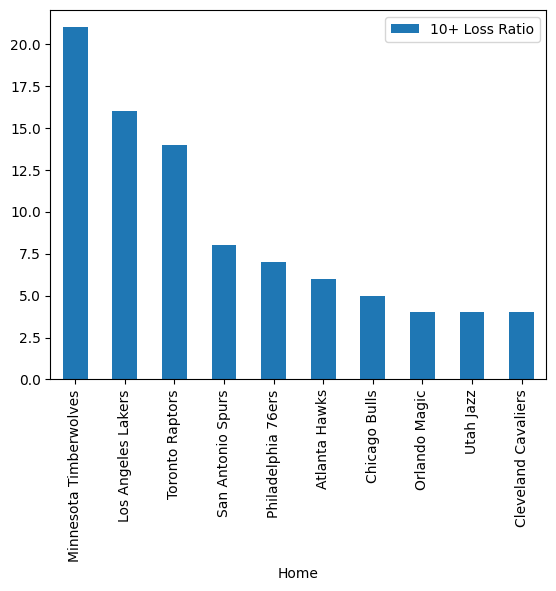

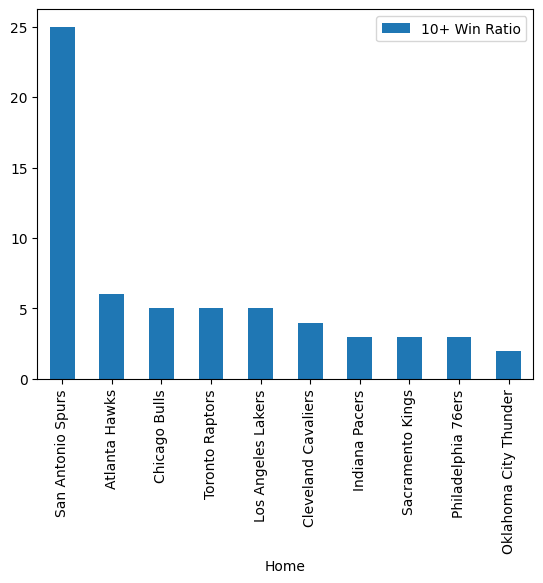

In [41]:
get_subset(deficit_count, "10+", False).head(10).plot.bar(x="Home", y="10+ Loss Ratio"), get_subset(deficit_count, "10+").head(10).plot.bar(x="Home", y="10+ Win Ratio")

(<Axes: xlabel='Home'>, <Axes: xlabel='Home'>)

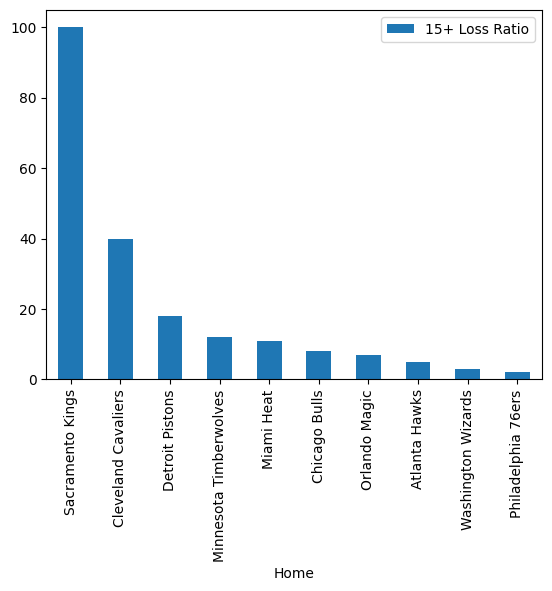

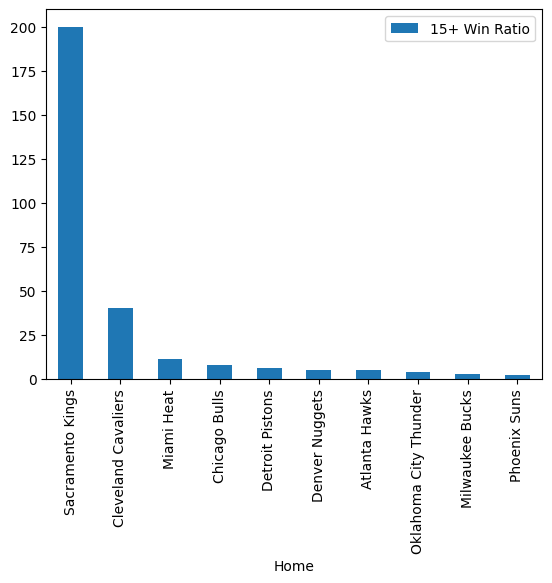

In [45]:
get_subset(deficit_count, "15+", False).dropna().head(10).plot.bar(x="Home", y="15+ Loss Ratio"), get_subset(deficit_count, "15+").dropna().head(10).plot.bar(x="Home", y="15+ Win Ratio")

(<Axes: xlabel='Home'>, <Axes: xlabel='Home'>)

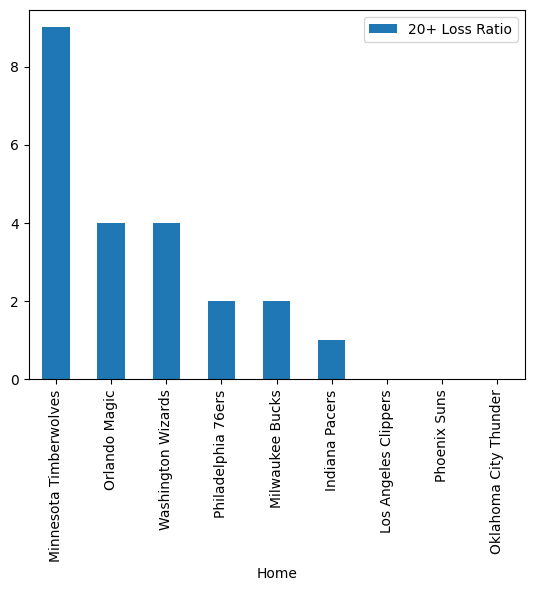

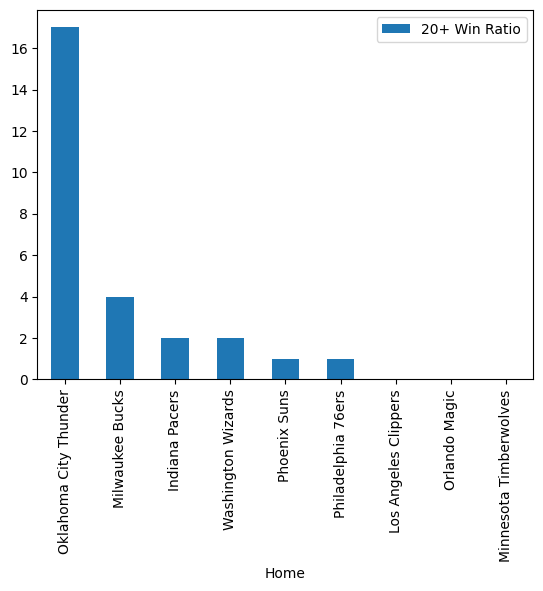

In [46]:
get_subset(deficit_count, "20+", False).dropna().head(10).plot.bar(x="Home", y="20+ Loss Ratio"), get_subset(deficit_count, "20+").dropna().head(10).plot.bar(x="Home", y="20+ Win Ratio")